# S6E6 - Predicting Stellar Class (V1)

Goal: predict `class` for the June Playground competition using a compact, interview-friendly workflow.

Plan:
1. ETL and data checks
2. Focused EDA
3. Baseline model
4. Better model
5. Kaggle-ready submission

## 1) Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Libraries loaded.")

Libraries loaded.


## 2) ETL: Load Data

In [ ]:
kaggle_path = "/kaggle/input/competitions/playground-series-s6e6"
def find_input_dir():
    if os.path.exists(kaggle_path):
        candidates = [p for p in os.listdir(kaggle_path) if os.path.isdir(os.path.join(kaggle_path, p))]
        for name in candidates:
            path = os.path.join(kaggle_path, name)
            if all(os.path.exists(os.path.join(path, f)) for f in ["train.csv", "test.csv", "sample_submission.csv"]):
                return path
        return kaggle_path
    return "./data"

input_dir = find_input_dir()
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "./submissions"
os.makedirs(output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(input_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(input_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(input_dir, "sample_submission.csv"))

TARGET = "class"
ID_COL = "id"
CLASS_ORDER = ["GALAXY", "QSO", "STAR"]

print(f"Input dir : {input_dir}")
print(f"Output dir: {output_dir}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
display(train_df.head(3))

Input dir : ./data
Output dir: ./submissions
Train shape: (577347, 12)
Test shape : (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO


In [3]:
missing_train = train_df.isna().sum().sum()
missing_test = test_df.isna().sum().sum()

print("Missing values (train):", int(missing_train))
print("Missing values (test) :", int(missing_test))
print("Duplicate ids (train) :", int(train_df[ID_COL].duplicated().sum()))
print("Duplicate ids (test)  :", int(test_df[ID_COL].duplicated().sum()))

class_counts = train_df[TARGET].value_counts()
print("Target distribution:")
print(class_counts)
print("Target ratios:")
print(train_df[TARGET].value_counts(normalize=True).round(4))

Missing values (train): 0
Missing values (test) : 0
Duplicate ids (train) : 0
Duplicate ids (test)  : 0
Target distribution:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
Target ratios:
class
GALAXY    0.6538
QSO       0.2029
STAR      0.1433
Name: proportion, dtype: float64


## 3) EDA

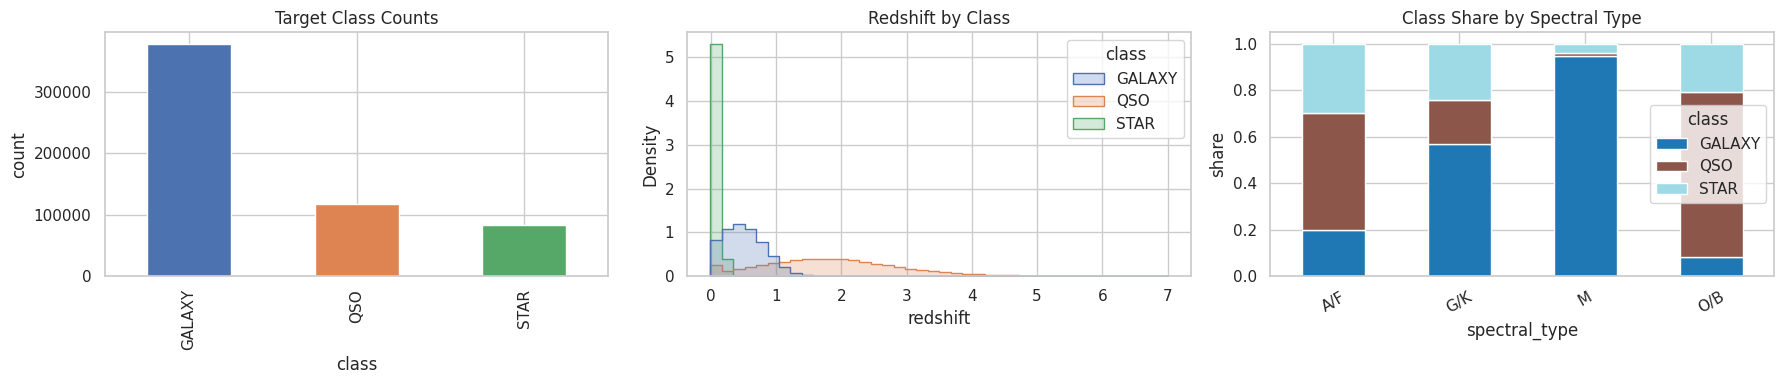

Quick read: class imbalance exists, redshift is likely informative, and spectral type should carry signal.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

class_counts.reindex(CLASS_ORDER).plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Target Class Counts")
axes[0].set_xlabel("class")
axes[0].set_ylabel("count")

sns.histplot(data=train_df, x="redshift", hue=TARGET, stat="density", common_norm=False, bins=40, element="step", ax=axes[1])
axes[1].set_title("Redshift by Class")

spectral_pivot = pd.crosstab(train_df["spectral_type"], train_df[TARGET], normalize="index")
spectral_pivot[[c for c in CLASS_ORDER if c in spectral_pivot.columns]].plot(kind="bar", stacked=True, ax=axes[2], colormap="tab20")
axes[2].set_title("Class Share by Spectral Type")
axes[2].set_ylabel("share")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Quick read: class imbalance exists, redshift is likely informative, and spectral type should carry signal.")

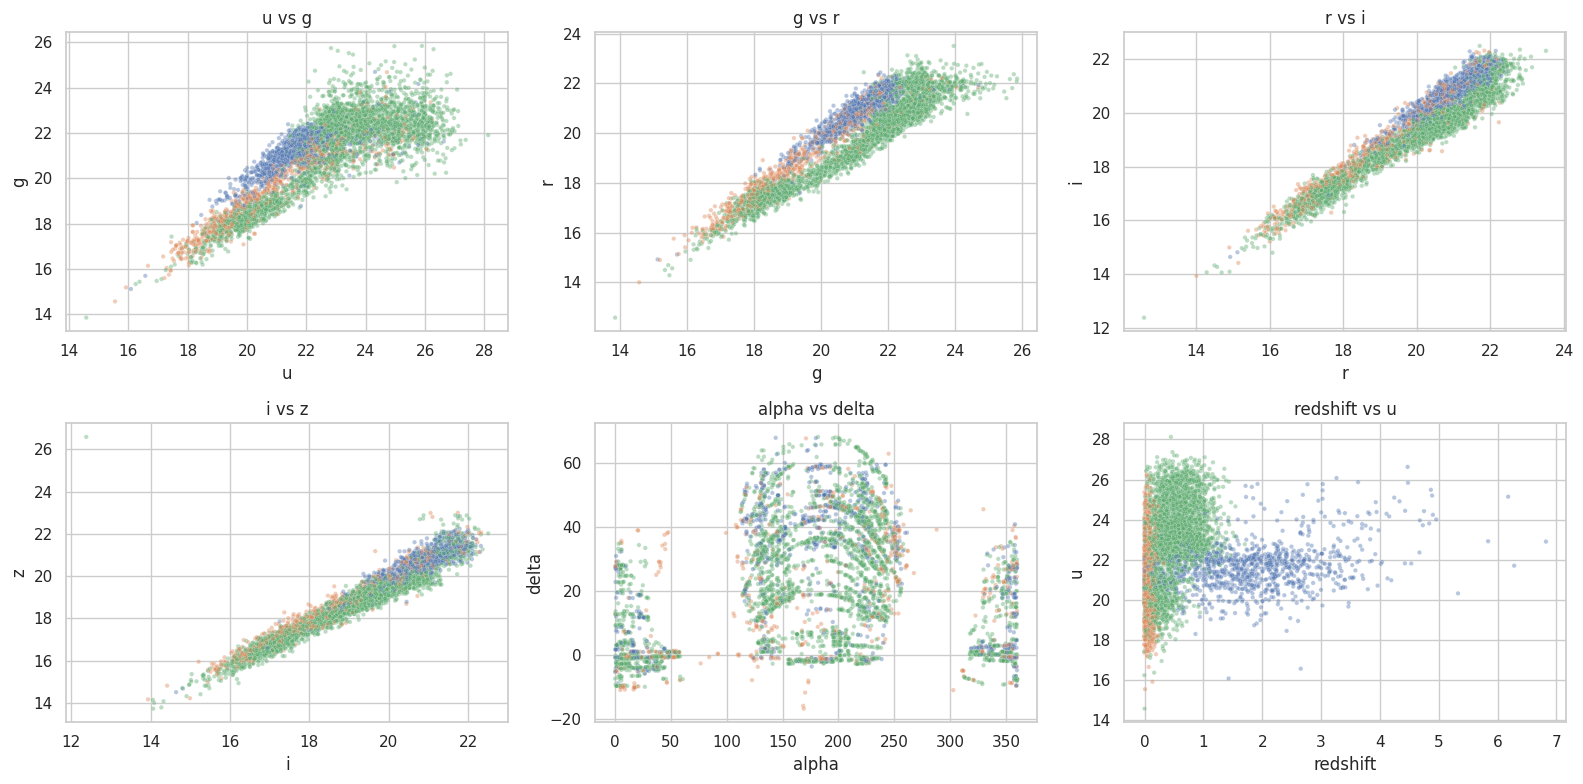

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
feature_pairs = [
    ("u", "g"),
    ("g", "r"),
    ("r", "i"),
    ("i", "z"),
    ("alpha", "delta"),
    ("redshift", "u")
]

for ax, (x_col, y_col) in zip(axes.ravel(), feature_pairs):
    sns.scatterplot(data=train_df.sample(5000, random_state=42), x=x_col, y=y_col, hue=TARGET, s=10, alpha=0.4, ax=ax, legend=False)
    ax.set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

## 4) Feature Engineering

In [5]:
def engineer_features(df):
    df = df.copy()

    # Color indices from the photometric bands
    df["u_g"] = df["u"] - df["g"]
    df["g_r"] = df["g"] - df["r"]
    df["r_i"] = df["r"] - df["i"]
    df["i_z"] = df["i"] - df["z"]
    df["u_r"] = df["u"] - df["r"]
    df["g_i"] = df["g"] - df["i"]
    df["r_z"] = df["r"] - df["z"]

    # Compact summary statistics for the band magnitudes
    band_cols = ["u", "g", "r", "i", "z"]
    df["band_mean"] = df[band_cols].mean(axis=1)
    df["band_std"] = df[band_cols].std(axis=1)
    df["band_min"] = df[band_cols].min(axis=1)
    df["band_max"] = df[band_cols].max(axis=1)
    df["band_range"] = df["band_max"] - df["band_min"]

    # Domain interactions
    df["alpha_delta_interaction"] = df["alpha"] * df["delta"]
    df["alpha_abs_delta"] = df["alpha"] / (df["delta"].abs() + 1.0)
    df["redshift_sq"] = df["redshift"] ** 2

    # Categorical combinations that often help boosted trees
    df["spectral__population"] = df["spectral_type"].astype(str) + "__" + df["galaxy_population"].astype(str)
    df["redshift_bin"] = pd.cut(
        df["redshift"],
        bins=[-np.inf, 0.2, 0.5, 1.0, 2.0, np.inf],
        labels=["very_low", "low", "mid", "high", "very_high"]
    ).astype(str)

    return df

train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

feature_cols = [c for c in train_fe.columns if c not in [ID_COL, TARGET]]
cat_cols = train_fe[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"Feature count: {len(feature_cols)}")
print(f"Categorical columns: {cat_cols}")
print(f"Numeric columns: {len(num_cols)}")
display(train_fe[feature_cols].head(3))

Feature count: 27
Categorical columns: ['spectral_type', 'galaxy_population', 'spectral__population', 'redshift_bin']
Numeric columns: 23


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,u_g,g_r,r_i,i_z,u_r,g_i,r_z,band_mean,band_std,band_min,band_max,band_range,alpha_delta_interaction,alpha_abs_delta,redshift_sq,spectral__population,redshift_bin
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,3.576564,1.537632,1.100813,0.636056,5.114196,2.638446,1.736869,21.120756,2.731221,18.621057,25.472123,6.851065,2505.465564,8.226071,0.167266,M__Red_Sequence,low
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,1.691447,1.499854,0.361141,0.439634,3.191300,1.860995,0.800775,18.293056,1.636652,16.786433,20.778509,3.992076,4140.013466,3.838119,0.024956,M__Red_Sequence,very_low
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,-0.043925,-0.092712,0.589211,0.025263,-0.136637,0.496499,0.614474,20.885233,0.292103,20.557366,21.171840,0.614474,6354.742913,4.946854,7.973677,O/B__Blue_Cloud,very_high


## 5) Prepare Targets and Matrices

In [6]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_fe[TARGET])
class_names = list(label_encoder.classes_)

X_lr = train_fe[feature_cols].copy()
X_test_lr = test_fe[feature_cols].copy()

# LightGBM wants numeric inputs; encode categoricals consistently on train/test
X_lgb = X_lr.copy()
X_test_lgb = X_test_lr.copy()
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_lgb[col], X_test_lgb[col]], axis=0).astype(str)
    le.fit(combined)
    X_lgb[col] = le.transform(X_lgb[col].astype(str))
    X_test_lgb[col] = le.transform(X_test_lgb[col].astype(str))

X_lgb = X_lgb.apply(pd.to_numeric, errors="coerce")
X_test_lgb = X_test_lgb.apply(pd.to_numeric, errors="coerce")
fill_values = X_lgb.median(numeric_only=True)
X_lgb = X_lgb.fillna(fill_values)
X_test_lgb = X_test_lgb.fillna(fill_values)

print(f"Encoded target classes: {class_names}")
print(f"X_lr shape: {X_lr.shape}, X_test_lr shape: {X_test_lr.shape}")
print(f"X_lgb shape: {X_lgb.shape}, X_test_lgb shape: {X_test_lgb.shape}")

Encoded target classes: ['GALAXY', 'QSO', 'STAR']
X_lr shape: (577347, 27), X_test_lr shape: (247435, 27)
X_lgb shape: (577347, 27), X_test_lgb shape: (247435, 27)


## 6) Baseline Model - Logistic Regression

In [9]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

numeric_features = [c for c in feature_cols if c not in cat_cols]
baseline_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

baseline_model = Pipeline(steps=[
    ("prep", baseline_preprocess),
    ("model", LogisticRegression(max_iter=400, class_weight="balanced", solver="lbfgs"))
])

/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refr

Baseline Logistic Regression balanced accuracy:
folds: [0.91749 0.91705 0.91674]
mean : 0.91709
std  : 0.00031
Saved baseline submission: ./submissions/submission_v1_baseline_logreg.csv

## 7) Better Model - LightGBM
  Fold 1: balanced accuracy = 0.96461  (trees: 841)
  Fold 2: balanced accuracy = 0.96345  (trees: 845)
  Fold 3: balanced accuracy = 0.96316  (trees: 918)
------------------------------------------------------------
LightGBM OOF balanced accuracy: 0.96374
Mean fold balanced accuracy   : 0.96374 +/- 0.00063
Baseline mean                 : 0.91709
Improvement                   : 0.04665


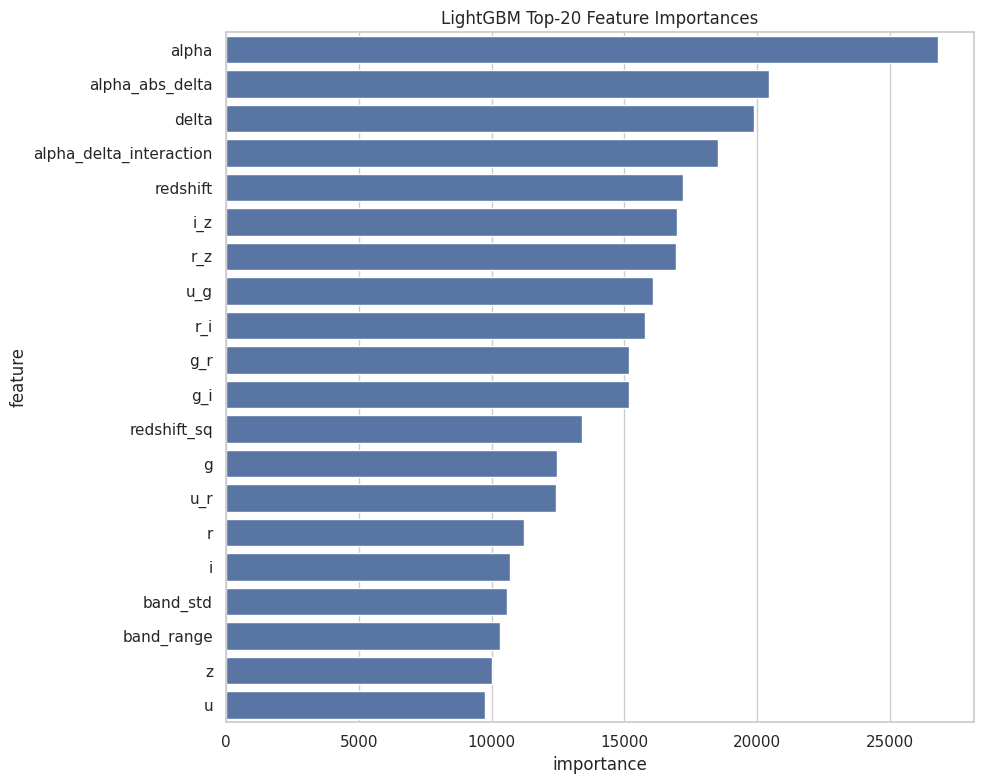

,feature,importance
0,alpha,26828.666667
1,alpha_abs_delta,20452.333333
8,delta,19882.666667
2,alpha_delta_interaction,18546.000000
18,redshift,17205.000000
14,i_z,16966.333333
17,r_z,16941.666667
24,u_g,16097.666667
16,r_i,15786.333333
11,g_r,15179.000000


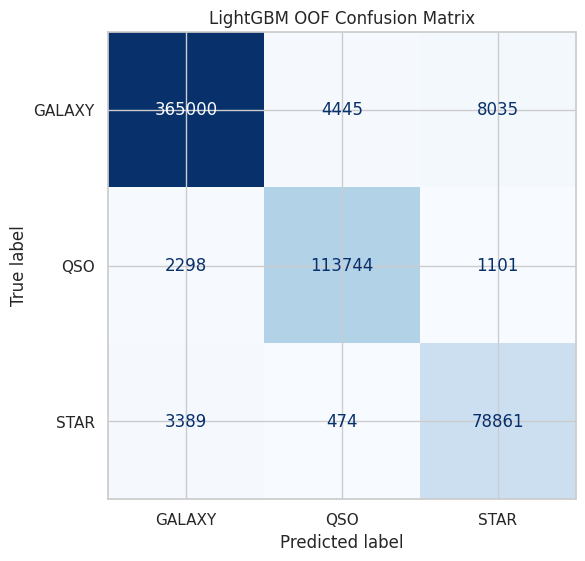


## 8) Final Submission
Saved improved submission: ./submissions/submission_v1_lgbm.csv
Saved Kaggle default submission: ./submissions/submission.csv
Test prediction class distribution:
GALAXY    158990
QSO        50823
STAR       37622
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY



## 9) Summary
- Baseline gives a clean reference point.
- LightGBM should usually beat the baseline on this tabular competition.
- Color indices and summary statistics are the most natural engineered features here.
- Balanced accuracy is the right metric to optimize for the leaderboard.


In [10]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

baseline_scores = cross_val_score(baseline_model, X_lr, y, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print("Baseline Logistic Regression balanced accuracy:")
print("folds:", np.round(baseline_scores, 5))
print("mean :", round(baseline_scores.mean(), 5))
print("std  :", round(baseline_scores.std(), 5))

baseline_model.fit(X_lr, y)
baseline_test_pred = baseline_model.predict(X_test_lr)
baseline_test_labels = label_encoder.inverse_transform(baseline_test_pred)

sub_baseline = sample_sub.copy()
sub_baseline[TARGET] = baseline_test_labels
baseline_path = os.path.join(output_dir, "submission_v1_baseline_logreg.csv")
sub_baseline.to_csv(baseline_path, index=False)
print(f"Saved baseline submission: {baseline_path}")

print("\n## 7) Better Model - LightGBM")
lgb_params = {
    "n_estimators": 1000,
    "learning_rate": 0.04,
    "num_leaves": 127,
    "min_child_samples": 80,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.3,
    "class_weight": "balanced",
    "objective": "multiclass",
    "num_class": len(class_names),
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

oof_lgb = np.zeros((len(X_lgb), len(class_names)))
test_lgb = np.zeros((len(X_test_lgb), len(class_names)))
fold_scores = []
fi_frames = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_lgb, y), start=1):
    X_tr, X_va = X_lgb.iloc[tr_idx], X_lgb.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)],
    )

    pred_va = model.predict_proba(X_va)
    pred_te = model.predict_proba(X_test_lgb)
    oof_lgb[va_idx] = pred_va
    test_lgb += pred_te / cv.n_splits

    fold_pred = np.argmax(pred_va, axis=1)
    fold_score = balanced_accuracy_score(y_va, fold_pred)
    fold_scores.append(fold_score)
    print(f"  Fold {fold}: balanced accuracy = {fold_score:.5f}  (trees: {model.best_iteration_})")

    fi_frames.append(pd.DataFrame({"feature": X_lgb.columns, "importance": model.feature_importances_, "fold": fold}))

oof_pred_labels = np.argmax(oof_lgb, axis=1)
oof_score = balanced_accuracy_score(y, oof_pred_labels)

print("-" * 60)
print(f"LightGBM OOF balanced accuracy: {oof_score:.5f}")
print(f"Mean fold balanced accuracy   : {np.mean(fold_scores):.5f} +/- {np.std(fold_scores):.5f}")
print(f"Baseline mean                 : {baseline_scores.mean():.5f}")
print(f"Improvement                   : {oof_score - baseline_scores.mean():.5f}")

fi = pd.concat(fi_frames, axis=0).groupby("feature", as_index=False)["importance"].mean().sort_values("importance", ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fi.head(20), x="importance", y="feature", color="#4C72B0")
plt.title("LightGBM Top-20 Feature Importances")
plt.tight_layout()
plt.show()
display(fi.head(10))

cm = confusion_matrix(y, oof_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("LightGBM OOF Confusion Matrix")
plt.tight_layout()
plt.show()

print("\n## 8) Final Submission")
final_labels = label_encoder.inverse_transform(np.argmax(test_lgb, axis=1))
submission = sample_sub.copy()
submission[TARGET] = final_labels
submission_path = os.path.join(output_dir, "submission_v1_lgbm.csv")
submission.to_csv(submission_path, index=False)
submission.to_csv(os.path.join(output_dir, "submission.csv"), index=False)
print("Saved improved submission:", submission_path)
print("Saved Kaggle default submission:", os.path.join(output_dir, "submission.csv"))
print("Test prediction class distribution:")
print(pd.Series(final_labels).value_counts())
display(submission.head(10))

print("\n## 9) Summary")
print("- Baseline gives a clean reference point.")
print("- LightGBM should usually beat the baseline on this tabular competition.")
print("- Color indices and summary statistics are the most natural engineered features here.")
print("- Balanced accuracy is the right metric to optimize for the leaderboard.")

In [11]:
baseline_scores = cross_val_score(baseline_model, X_lr, y, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
print("Baseline Logistic Regression balanced accuracy:")
print("folds:", np.round(baseline_scores, 5))
print("mean :", round(baseline_scores.mean(), 5))
print("std  :", round(baseline_scores.std(), 5))

baseline_model.fit(X_lr, y)
baseline_test_pred = baseline_model.predict(X_test_lr)
baseline_test_labels = label_encoder.inverse_transform(baseline_test_pred)

sub_baseline = sample_sub.copy()
sub_baseline[TARGET] = baseline_test_labels
baseline_path = os.path.join(output_dir, "submission_v1_baseline_logreg.csv")
sub_baseline.to_csv(baseline_path, index=False)
print(f"Saved baseline submission: {baseline_path}")

/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shiftmint/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refr

Baseline Logistic Regression balanced accuracy:
folds: [0.91749 0.91705 0.91674]
mean : 0.91709
std  : 0.00031
Saved baseline submission: ./submissions/submission_v1_baseline_logreg.csv
